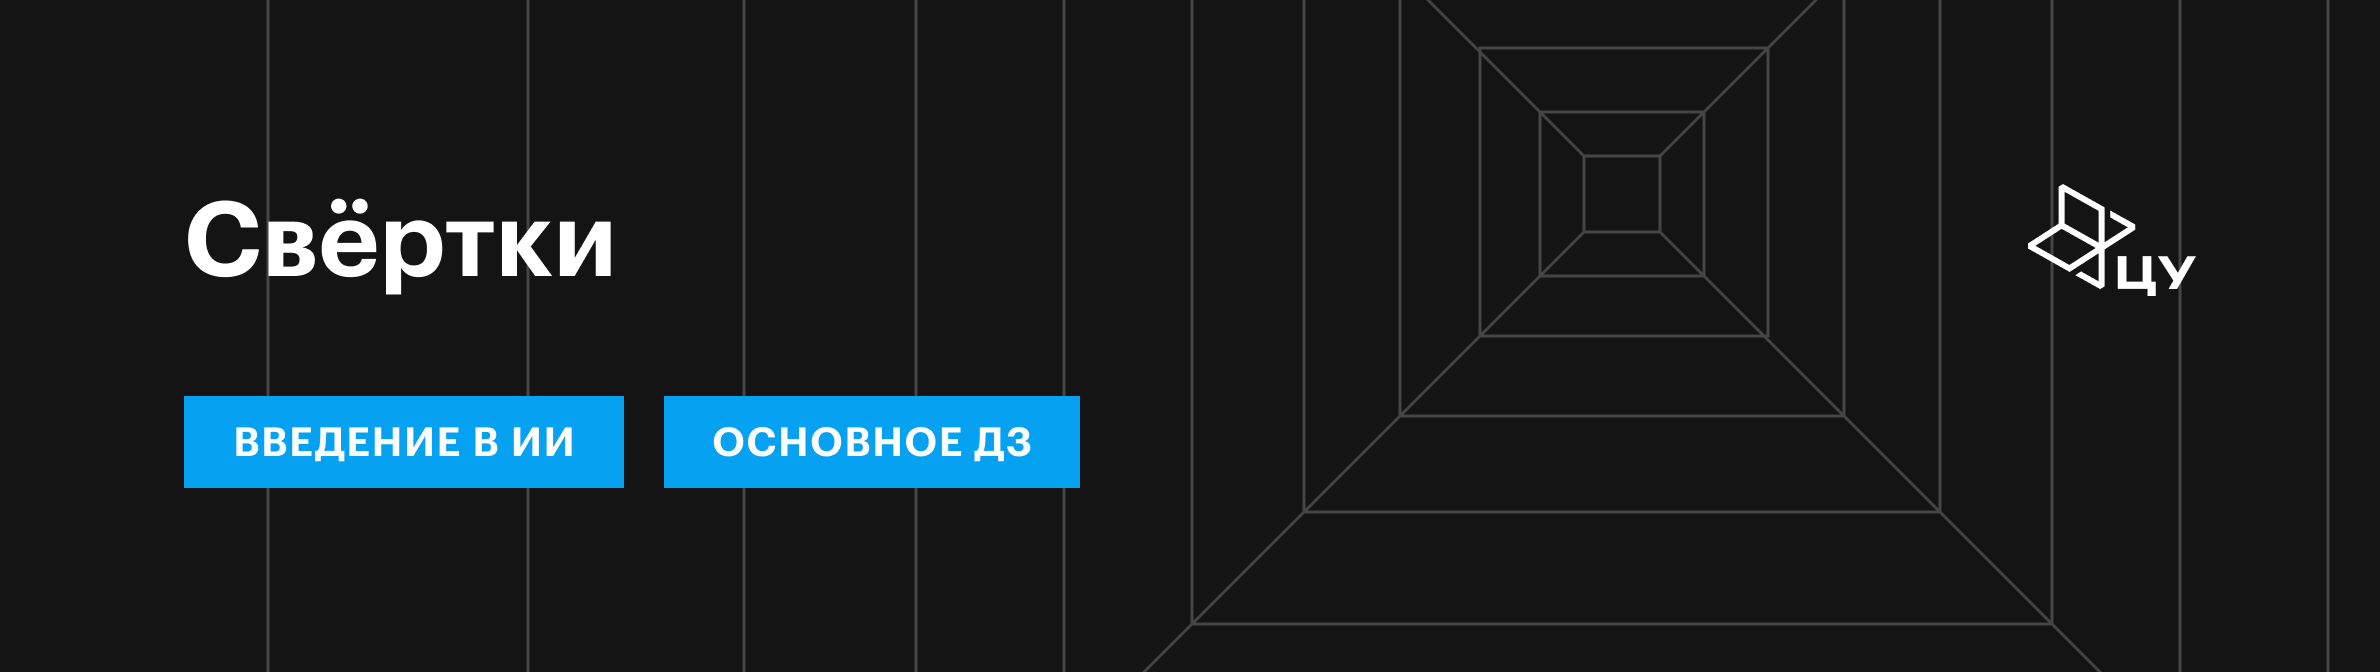

# Домашнее задание по теме «Свёртки»



В этом домашнем задании ты поработаешь с базовыми операциями обработки изображений, которые тесно связаны с темой свёрток и фильтров.

Тебе предстоит:

- добавить к изображению разные виды шума;
- применить фильтры для удаления шума и сравнить их работу;
- исследовать, как операторы выделения границ реагируют на искажения изображения;
- сделать выводы о том, какие методы лучше сохраняют полезные детали, а какие проявляют большую чувствительность к шуму.

Цель этого домашнего задания — не только реализовать нужные преобразования, но и понять, как шум, сглаживание и выделение границ связаны между собой на практике.

>### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.

## Импорт пакетов

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!gdown 15uFEMCKuBQWRuTO32wSmxWQukBGtnADA
!unzip -q /content/kodak.zip

Downloading...
From: https://drive.google.com/uc?id=15uFEMCKuBQWRuTO32wSmxWQukBGtnADA
To: /content/kodak.zip
100% 6.38M/6.38M [00:00<00:00, 198MB/s]


## Вспомогательная функция для визуализации результатов

In [3]:
import torch

def plot_images(images, titles=None, fontsize=20, figsize=(10, 10), save_path=None):

    n_images = len(images)

    fig, axs = plt.subplots(1, n_images, figsize=figsize)

    for i in range(n_images):
        img = images[i]

        # Переводит всё в numpy
        if isinstance(img, torch.Tensor):
            if len(img.shape)==4:
                img = img[0]
            if img.shape[0] == 1:
                img = img[0]
            else:
                img = img.permute(1, 2, 0)
            arr = img.numpy()
        else: # Считаем, что иначе numpy-массив
            if img.dtype == np.uint8:
                img = img / 255
            arr = img.astype(np.float32)

        # Визуализация
        axs[i].imshow(arr, cmap=("gray" if arr.ndim == 2 else None))
        axs[i].axis("off")

        # Названия
        if titles:
            axs[i].set_title(titles[i], fontsize=fontsize)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

### Задание 1. Добавление шума к изображению [3 балла]

В этом задании тебе нужно испортить изображение двумя различными способами.


### Часть 1. Подготовка изображения [0,6 балла]

1. Переведи изображение в формат grayscale.
2. Визуализируй исходное изображение.

 Для визуализации можно использовать функцию `plot_images` из прошлого домашнего задания.


### Часть 2. Gaussian noise [1,2 балла]

Добавь к изображению гауссовский шум.

Пусть шум имеет распределение:

$$
\varepsilon \sim \ {N}(0, \sigma^2),
$$

где $\sigma$ — стандартное отклонение (попробуй несколько значений, например $10$, $20$, $40$).

Инструкция.

1. Сгенерируй шум такого же размера, что и изображение.
2. Прибавь его к изображению.
3. Ограничь значения пикселей диапазоном $[0, 255]$.
4. Приведи результат к типу `uint8`.
5. Визуализируй результат.


### Часть 3. Salt & Pepper noise [1,2 балла]

Добавь к изображению случайные:
- чёрные пиксели,
- белые пиксели.

Пусть вероятность искажения пикселя равна $p$ (попробуй значения $0,01$; $0,03$; $0,1$).

Инструкция.

1. Скопируй исходное изображение.
2. Для случайной доли пикселей:
   - одну половину замени на $0$,
   - вторую половину замени на $255$.
3. Визуализируй результат.



### Что должно получиться

В конце у тебя должны быть визуализированы:

- исходное изображение (grayscale),
- изображение с Gaussian noise,
- изображение с Salt & Pepper noise.

Сравни, как визуально отличаются эти два типа шума.


#### Твоё решение

In [4]:
img = cv2.imread("kodak/kodim07.png")

# Напиши код здесь

In [7]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [45]:
noise = np.random.normal(0, 20, gray_img.shape).astype(np.uint8)
noise_img = np.clip(gray_img + noise, 0, 255).astype(np.uint8)

In [46]:
p = 0.03
salt_img = gray_img.copy()
mask = np.random.uniform(size = salt_img.shape)
salt_img[mask < (p / 2)] = 0
salt_img[mask > 1 - (p / 2)] = 255

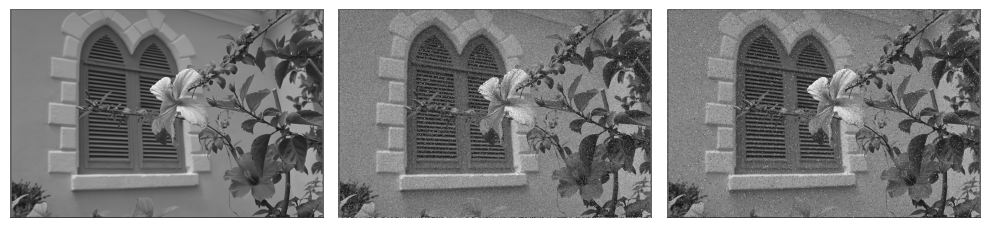

In [47]:
plot_images([gray_img, noise_img, salt_img])

### Задание 2. Удаление шума [3 балла]

В этом задании тебе нужно убрать шум с изображений, полученных в задании 1.

### Часть 1. Применение фильтров [1,5 балла]

Примени минимум 3 фильтра из списка [0,5 балла за каждый фильтр]:

- Mean filter (`cv2.blur`),
- Gaussian filter (`cv2.GaussianBlur`),
- Median filter (`cv2.medianBlur`),
- Bilateral filter (`cv2.bilateralFilter`) — по желанию.

Для каждого фильтра:

- подбери параметры (размер ядра, $\sigma$ и так далее);
- примени фильтр к зашумлённому изображению;
- визуализируй результат.


### Часть 2. Сравнение результатов [1,5 балла]

Ответь на вопросы.

1. **[0,4 балла]** Какой фильтр лучше справился с Gaussian noise?
2. **[0,4 балла]** Какой фильтр лучше справился с Salt & Pepper noise?
3. **[0,4 балла]** Какие фильтры сильнее размывают детали изображения?
4. **[0,3 балла]** Легко ли было подобрать параметры?







#### Твоё решение

In [118]:
mean_blur = cv2.blur(noise_img, (5, 5))
gauss_blur = cv2.GaussianBlur(noise_img, (9, 9), 10)
median_blur = cv2.medianBlur(salt_img, 5)
bilateral_blur = cv2.bilateralFilter(noise_img, 9, 75, 75)

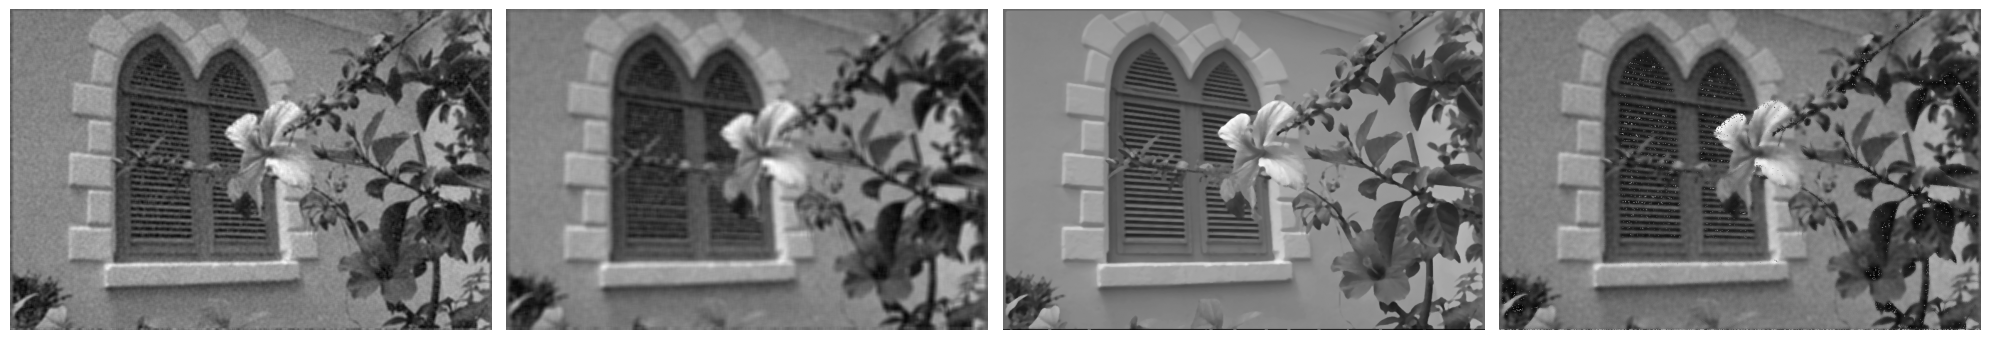

In [119]:
plot_images([mean_blur, gauss_blur, median_blur, bilateral_blur], figsize=(20, 20))

1. билатерал вроде лучше, но у меня получилось нормально только salt убрать
2. medianblur, хорошо убирает выбросы
3. гаусс сильно размывает
4. нет

In [129]:
denoise_img = median_blur

### Задание 3. Устойчивость операторов границ к шуму [4 балла]

В этом задании тебе нужно выяснить, как разные операторы выделения границ реагируют на шум.

Работай с тремя изображениями:

- исходное изображение,
- изображение с Gaussian noise,
- изображение после денойзинга.


### Часть 1. Применение операторов [1 балл]

Для каждого из трёх изображений примени:

- классический градиент,
- градиент Собеля,
- фильтр высоких частот.

Для градиентных методов вычисли модуль градиента:

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}.
$$

Визуализируй результаты.

> **Важно.** Рекомендуется использовать функцию `plot_images`.

### Часть 2. Количественное сравнение [1 балл]

Для каждого результата посчитай одну простую характеристику, например среднее значение модуля градиента:

$$
\text{mean}(|\nabla I|).
$$

Или долю пикселей выше некоторого порога.

Сравни значения для изображений:
- исходного,
- зашумлённого,
- очищенного.


### Часть 3. Анализ [2 балла]

Ответь на вопросы:

1. **[0,5 балла]** Какой оператор сильнее всего реагирует на шум?
2. **[0,5 балла]** Какой оператор наиболее устойчив?
3. **[0,5 балла]** Почему фильтры высоких частот усиливают шум?
4. **[0,5 балла]** Почему Собель обычно даёт более стабильный результат, чем простой разностный оператор?



#### Твоё решение

In [130]:
def gradient(gray):
    kx = np.array([[-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1], [0], [1]], dtype=np.float32)

    gx = cv2.filter2D(gray, ddepth=-1, kernel=kx)
    gy = cv2.filter2D(gray, ddepth=-1, kernel=ky)

    mag = np.sqrt(gx**2 + gy**2)
    return gx, gy, mag

def sobel_filter(gray, ksize=3):
    gx = cv2.Sobel(gray, cv2.CV_32F, dx=1, dy=0, ksize=ksize)
    gy = cv2.Sobel(gray, cv2.CV_32F, dx=0, dy=1, ksize=ksize)
    magnitude = np.sqrt(gx**2 + gy**2)
    return gx, gy, magnitude

def high_pass_filter(gray, ksize=9, sigma=2.0):
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigmaX=sigma)
    high = gray - blurred
    return high

In [131]:
def gr(img):
    gx, gy, mag = gradient(img)
    return mag

def sobel(img):
    gx, gy, mag = sobel_filter(img)
    return mag


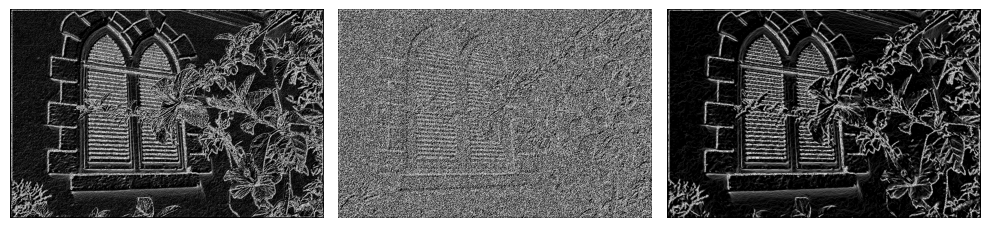

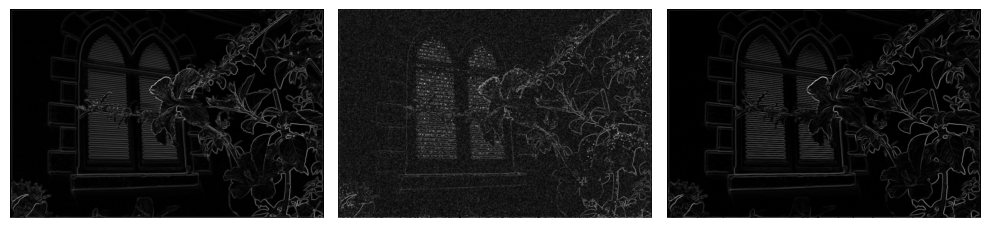

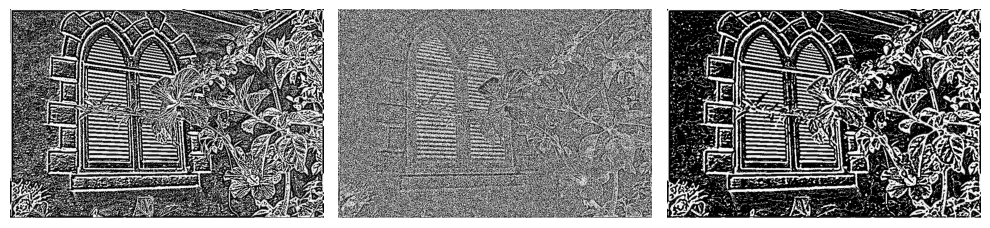

In [132]:
plot_images([gr(gray_img), gr(noise_img), gr(denoise_img)])
plot_images([sobel(gray_img), sobel(noise_img), sobel(denoise_img)])
plot_images([high_pass_filter(gray_img), high_pass_filter(noise_img), high_pass_filter(denoise_img)])

In [137]:
def mn(img):
    return np.mean(np.abs(img))


In [140]:
images = {
    "original": gray_img,
    "noisy": noise_img,
    "denoised": denoise_img
}

for funct in [gr, sobel, high_pass_filter]:
    print(funct.__name__)
    for name, img in images.items():
        print(f"  {name}: {mn(funct(img)):.2f}")

gr
  original: 3.70
  noisy: 6.95
  denoised: 2.61
sobel
  original: 52.92
  noisy: 114.05
  denoised: 35.57
high_pass_filter
  original: 106.30
  noisy: 127.44
  denoised: 86.15


1. high pass очень сильно реагирует
2. собел выглядит устойчивым, потому что реагирует и не шумит
3. шум состоит из того что оператор выделяет соседние пиксели и выделяет их разницу
4. так как он дополнительно делает небольшое сглаживание

Напиши ответы здесь.